<a href="https://colab.research.google.com/github/krawinkele/HerramientasBasicas-Krawinkel-Erika/blob/main/Herramientasb%C3%A1sicas_Krawinkel_Erika.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Trabajo Final - Herramientas Básicas

**Bienestar mental y patrones de estilo de vida digital de la Generación Z**

##Descripción del dataset


El dataset utilizado contiene información sobre hábitos digitales, características demográficas y variables emocionales de individuos pertenecientes a la Generación Z. Su objetivo es analizar cómo distintos factores del estilo de vida, especialmente el uso de la tecnología, se relacionan con el bienestar emocional y el riesgo de burnout.

Entre las variables incluidas se encuentran datos como la edad, el género, las horas de uso de dispositivos digitales (por ejemplo, tiempo en redes sociales, gaming online y uso nocturno del celular), así como indicadores psicológicos como el nivel de ansiedad, la fatiga emocional y la motivación.

##Búsqueda y selección del dataset



*   Fuente: https://www.kaggle.com/datasets/hammadansari7/gen-z-mental-wellness-and-digital-lifestyle-patterns?select=genz_mental_wellness_synthetic_dataset.csv

Preguntas de análisis:
1.   ¿Qué factores del estilo de vida digital y demográfico influyen en el riesgo de burnout en la Generación Z?
2.   ¿Cómo influye la cantidad y calidad del sueño en el riesgo de burnout?
3.   ¿Qué relación existe entre las horas de gaming online y los niveles de ansiedad y fatiga emocional?






In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3


from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [12]:
bienestar = pd.read_csv('/content/drive/MyDrive/Análisis de datos - Programas/TP/Bienestar mental y patrones de estilo de vida digital de la Generación Z (1).csv', sep=';')

##Exploración estructural y estadística

###Leer el dataset en Python.


In [3]:
bienestar.head()

,Age,Gender,Country,Student_Working_Status,Daily_Social_Media_Hours,Screen_Time_Hours,Night_Scrolling_Frequency,Online_Gaming_Hours,Content_Type_Preference,Exercise_Frequency_per_Week,...,Study_Work_Hours_per_Day,Overthinking_Score,Anxiety_Score,Mood_Stability_Score,Social_Comparison_Index,Sleep_Quality_Score,Motivation_Level,Emotional_Fatigue_Score,Wellbeing_Index,Burnout_Risk
0,24,Male,Canada,Working,4.81,6.93,2.61,2.07,News,5.41,...,11.42,4.95,4.13,5.74,4.67,6.27,6.13,6.45,4.28,Medium
1,21,Male,USA,Student,4.16,7.94,1.85,3.58,Gaming,3.41,...,6.98,5.91,3.63,5.75,5.38,7.37,6.27,3.74,5.23,Medium
2,25,Male,Pakistan,Student,3.07,7.45,2.96,2.85,Entertainment,3.40,...,7.79,4.06,5.67,6.03,2.41,6.48,4.82,6.69,3.72,High
3,22,Female,Pakistan,Student,4.41,7.34,4.51,3.37,Educational,2.19,...,6.61,6.10,4.78,4.85,5.86,7.27,5.17,5.96,3.97,High
4,24,Male,Pakistan,Student,2.97,5.76,2.36,1.77,Educational,4.93,...,4.81,5.22,4.23,5.05,5.54,6.34,5.72,2.22,4.63,Medium


In [ ]:
bienestar.columns

Index(['Age', 'Gender', 'Country', 'Student_Working_Status',
       'Daily_Social_Media_Hours', 'Screen_Time_Hours',
       'Night_Scrolling_Frequency', 'Online_Gaming_Hours',
       'Content_Type_Preference', 'Exercise_Frequency_per_Week',
       'Daily_Sleep_Hours', 'Caffeine_Intake_Cups', 'Study_Work_Hours_per_Day',
       'Overthinking_Score', 'Anxiety_Score', 'Mood_Stability_Score',
       'Social_Comparison_Index', 'Sleep_Quality_Score', 'Motivation_Level',
       'Emotional_Fatigue_Score', 'Wellbeing_Index', 'Burnout_Risk'],
      dtype='object')

In [ ]:
bienestar.shape

(10000, 22)

In [ ]:
bienestar.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 22 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Age                          10000 non-null  int64  
 1   Gender                       10000 non-null  object 
 2   Country                      10000 non-null  object 
 3   Student_Working_Status       10000 non-null  object 
 4   Daily_Social_Media_Hours     10000 non-null  float64
 5   Screen_Time_Hours            10000 non-null  float64
 6   Night_Scrolling_Frequency    10000 non-null  float64
 7   Online_Gaming_Hours          10000 non-null  float64
 8   Content_Type_Preference      10000 non-null  object 
 9   Exercise_Frequency_per_Week  10000 non-null  float64
 10  Daily_Sleep_Hours            10000 non-null  float64
 11  Caffeine_Intake_Cups         10000 non-null  float64
 12  Study_Work_Hours_per_Day     10000 non-null  float64
 13  Overthinking_Scor

In [ ]:
bienestar['Burnout_Risk'].value_counts()

,count
Burnout_Risk,
High,5388
Medium,4548
Low,64


###Diccionario

In [ ]:
traduccion = {
    "Age": "Edad",
    "Gender": "Género",
    "Country": "País",
    "Student_Working_Status": "Estado (Estudiante/Trabajando)",
    "Daily_Social_Media_Hours": "Horas diarias en redes sociales",
    "Screen_Time_Hours": "Horas de uso de pantallas",
    "Night_Scrolling_Frequency": "Frecuencia de uso nocturno",
    "Online_Gaming_Hours": "Horas de gaming online",
    "Content_Type_Preference": "Tipo de contenido preferido",
    "Exercise_Frequency_per_Week": "Frecuencia de ejercicio por semana",
    "Daily_Sleep_Hours": "Horas de sueño diarias",
    "Caffeine_Intake_Cups": "Consumo de cafeína (tazas)",
    "Study_Work_Hours_per_Day": "Horas de estudio/trabajo por día",
    "Overthinking_Score": "Puntaje de sobrepensamiento",
    "Anxiety_Score": "Puntaje de ansiedad",
    "Mood_Stability_Score": "Estabilidad del estado de ánimo",
    "Social_Comparison_Index": "Índice de comparación social",
    "Sleep_Quality_Score": "Calidad del sueño",
    "Motivation_Level": "Nivel de motivación",
    "Emotional_Fatigue_Score": "Fatiga emocional",
    "Wellbeing_Index": "Índice de bienestar",
    "Burnout_Risk": "Riesgo de burnout"
}

Traduje los nombres de las columnas para optimizar la interpretación del dataset y asegurar una correcta visualización de los datos.

###Auditar tipos, nulos, duplicados y outliers

In [ ]:
print(bienestar.isnull().sum())

Age                            0
Gender                         0
Country                        0
Student_Working_Status         0
Daily_Social_Media_Hours       0
Screen_Time_Hours              0
Night_Scrolling_Frequency      0
Online_Gaming_Hours            0
Content_Type_Preference        0
Exercise_Frequency_per_Week    0
Daily_Sleep_Hours              0
Caffeine_Intake_Cups           0
Study_Work_Hours_per_Day       0
Overthinking_Score             0
Anxiety_Score                  0
Mood_Stability_Score           0
Social_Comparison_Index        0
Sleep_Quality_Score            0
Motivation_Level               0
Emotional_Fatigue_Score        0
Wellbeing_Index                0
Burnout_Risk                   0
dtype: int64


Verifiqué que en el dataset no se encontrara ningun valor faltante.

In [ ]:
bienestar.duplicated().sum()

np.int64(0)

Validé que no haya ningun dato duplicado en el dataset.

In [ ]:
bienestar = bienestar.drop(columns=[
    'Country',
    'Content_Type_Preference',
    'Exercise_Frequency_per_Week',
    'Caffeine_Intake_Cups',
    'Social_Comparison_Index'
])

Eliminé variables que no aportaban valor directo a las preguntas de investigación.

###Estandarizar fechas, categorías y unidades

In [ ]:
bienestar['Gender'] = bienestar['Gender'].str.strip().str.title()
bienestar['Gender'] = bienestar['Gender'].replace({'M': 'Male', 'F': 'Female'})
print(bienestar['Gender'].unique())

['Male' 'Female' 'Non-Binary']


Se estandarizó la variable “Gender”, corrigiendo formato y unificando valores para evitar inconsistencias, y se verificaron sus valores únicos.

###KPIs y métricas clave

**Promedio de ansiedad:**  Permite medir el nivel general de ansiedad en la población analizada.

In [ ]:
bienestar['Anxiety_Score'].mean()

np.float64(4.747555999999999)

**Porcentaje de burnout:** indica la proporción de individuos con mayor riesgo.

In [ ]:
(bienestar['Burnout_Risk'] == 'High').mean() * 100

np.float64(53.879999999999995)

**Promedio de horas de gaming:** Refleja el nivel de exposición a actividades digitales recreativas.

In [7]:
bienestar['Online_Gaming_Hours'].mean()

np.float64(1.607241)

**Promedio de horas en redes sociales:** Refleja el nivel de exposición diaria a plataformas sociales digitales.

In [9]:
bienestar['Daily_Social_Media_Hours'].mean()

np.float64(4.005883)

**Promedio de uso de pantallas:** Mide la exposición general a dispositivos digitales.

In [ ]:
bienestar['Screen_Time_Hours'].mean()

np.float64(7.016991)

Los KPIs muestran un alto nivel de exposición a pantallas junto con una proporción significativa de personas con riesgo elevado de burnout, lo que refuerza la relevancia de analizar la relación entre hábitos digitales y bienestar emocional en la Generación Z.

##Exploración y visualización

###¿Qué factores del estilo de vida digital y demográfico influyen en el riesgo de burnout en la Generación Z?

**Edad - Burnout**

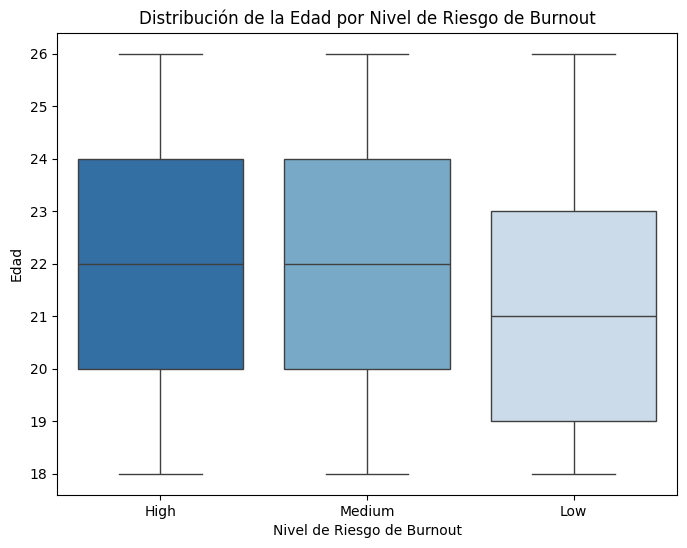

In [ ]:
plt.figure(figsize=(8, 6))

palette = sns.color_palette("Blues", 3)

custom_palette = {
    'High': palette[2],
    'Medium': palette[1],
    'Low': palette[0]
}

sns.boxplot(
    data=bienestar,
    x='Burnout_Risk',
    y='Age',
    order=['High', 'Medium', 'Low'],
    hue='Burnout_Risk',
    palette=custom_palette,
    legend=False
)

plt.title('Distribución de la Edad por Nivel de Riesgo de Burnout')
plt.xlabel('Nivel de Riesgo de Burnout')
plt.ylabel('Edad')

plt.show()

No parece haber una diferencia fuerte de edad entre quienes tienen burnout alto, medio o bajo.

 **Género -Burnout**

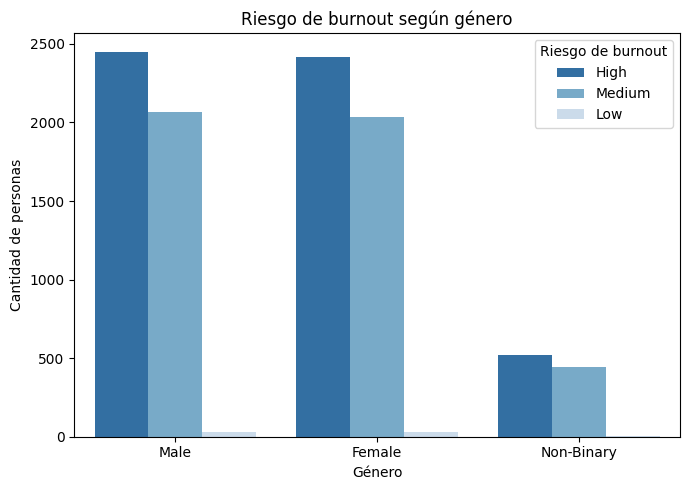

In [ ]:
palette = sns.color_palette("Blues", 3)

custom_palette = {
    'High': palette[2],
    'Medium': palette[1],
    'Low': palette[0]
}

plt.figure(figsize=(7,5))

sns.countplot(
    data=bienestar,
    x='Gender',
    hue='Burnout_Risk',
    hue_order=['High', 'Medium', 'Low'],
    palette=custom_palette
)

plt.title("Riesgo de burnout según género")
plt.xlabel("Género")
plt.ylabel("Cantidad de personas")

plt.legend(title="Riesgo de burnout")

plt.tight_layout()
plt.show()

No se observan diferencias relevantes en la distribución del riesgo de burnout según género, ya que las cantidades en cada nivel se mantienen similares entre los grupos.

**Sueño - Burnout**

/tmp/ipykernel_319/2316464796.py:26: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title="Riesgo de Burnout")


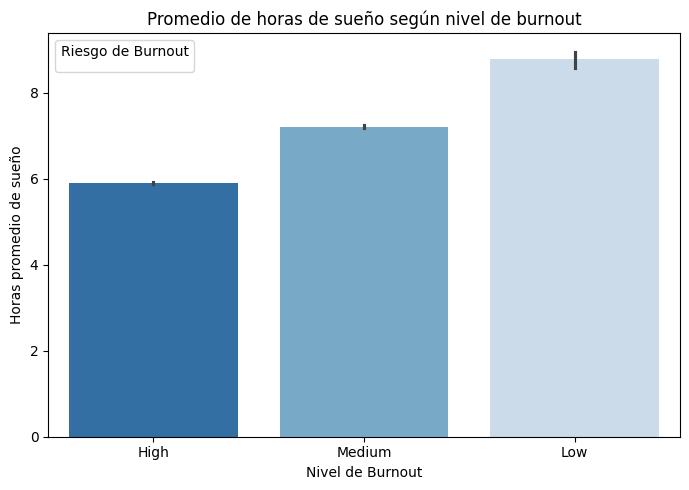

In [ ]:
plt.figure(figsize=(7,5))

palette = sns.color_palette("Blues", 3)

custom_palette = {
    'High': palette[2],
    'Medium': palette[1],
    'Low': palette[0]
}

sns.barplot(
    data=bienestar,
    x='Burnout_Risk',
    y='Daily_Sleep_Hours',
    order=['High', 'Medium', 'Low'],
    hue='Burnout_Risk',
    hue_order=['High', 'Medium', 'Low'],
    palette=custom_palette,
    estimator=np.mean
)

plt.title("Promedio de horas de sueño según nivel de burnout")
plt.xlabel("Nivel de Burnout")
plt.ylabel("Horas promedio de sueño")

plt.legend(title="Riesgo de Burnout")
plt.tight_layout()
plt.show()

El gráfico muestra que las personas con un mayor riesgo de burnout tienden a tener un promedio de horas de sueño más bajo, mientras que aquellos con un riesgo bajo de burnout duermen más horas en promedio.

**Pantalla - Burnout**

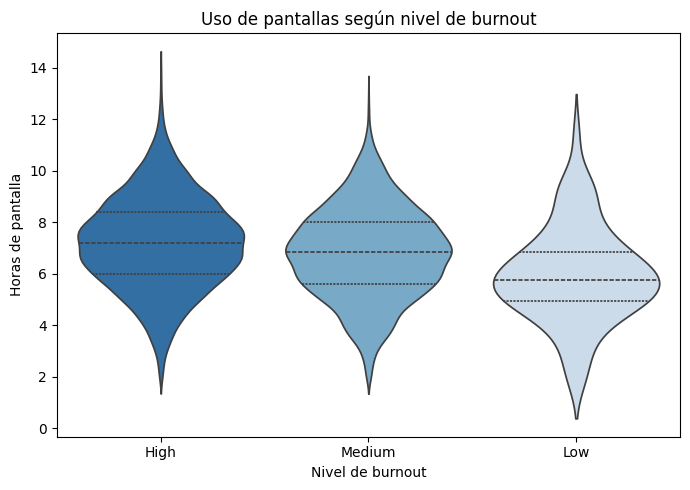

In [ ]:
plt.figure(figsize=(7, 5))

palette = sns.color_palette("Blues", 3)

custom_palette = {
    'High': palette[2],
    'Medium': palette[1],
    'Low': palette[0]
}

ax = sns.violinplot(
    data=bienestar,
    x='Burnout_Risk',
    y='Screen_Time_Hours',
    hue='Burnout_Risk',
    palette=custom_palette,
    order=['High', 'Medium', 'Low'],
    hue_order=['High', 'Medium', 'Low'],
    inner='quartile'
)

plt.title("Uso de pantallas según nivel de burnout")
plt.xlabel("Nivel de burnout")
plt.ylabel("Horas de pantalla")

legend = ax.get_legend()
if legend:
    legend.set_title('Riesgo de Burnout')
    legend.set_bbox_to_anchor((1.05, 1))
    legend.loc = 'upper left'

plt.tight_layout()
plt.show()

Si bien se aprecia una leve tendencia a mayor uso de pantallas en niveles más altos de burnout, las diferencias no son marcadas, por lo que no se puede afirmar una relación fuerte entre ambas variables.

### ¿Cómo influye la cantidad y calidad del sueño en el riesgo de burnout?

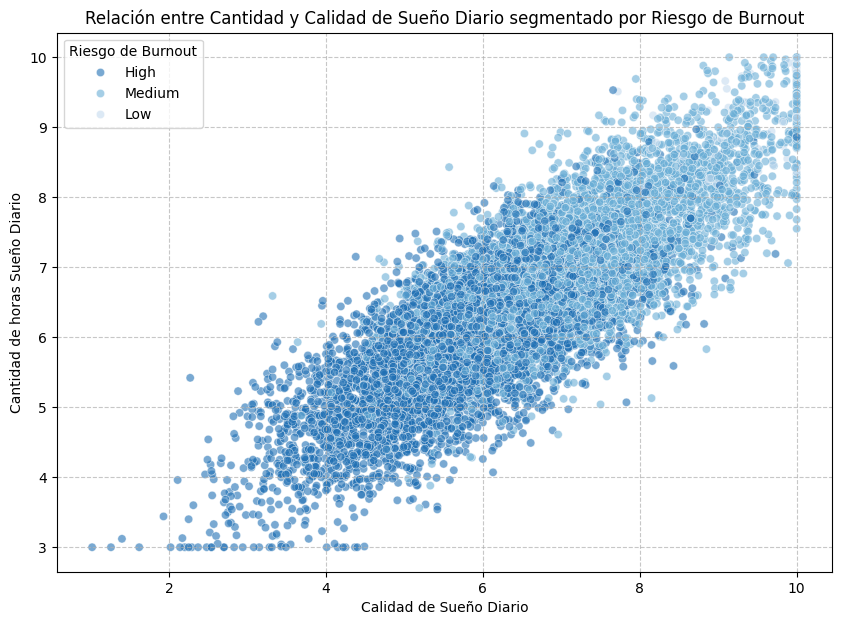

In [ ]:
plt.figure(figsize=(10, 7))
palette = sns.color_palette("Blues", 3)
custom_palette = {
    'High': palette[2],
    'Medium': palette[1],
    'Low': palette[0]
}
sns.scatterplot(
    data=bienestar,
    x='Sleep_Quality_Score',
    y='Daily_Sleep_Hours',
    hue='Burnout_Risk',
    hue_order=['High', 'Medium', 'Low'],
    palette=custom_palette,
    alpha=0.6
)
plt.title('Relación entre Cantidad y Calidad de Sueño Diario segmentado por Riesgo de Burnout')
plt.xlabel('Calidad de Sueño Diario')
plt.ylabel('Cantidad de horas Sueño Diario')
plt.legend(title='Riesgo de Burnout')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()




Se observa una correlación positiva y significativa entre la calidad de sueño y la cantidad de horas de sueño. Ahora bien, cuando comparamos ambas variables con el riesgo de burnout, se reporta una correlación fuertemente negativa, lo que en principio permite inferir que tanto pocas horas de sueño como poca calidad tienden a incrementar el riesgo de burnout.

### ¿Qué relación existe entre las horas de gaming online y los niveles de ansiedad y fatiga emocional?

/tmp/ipykernel_11551/4082554407.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grupo = bienestar.groupby('Gaming_grupos')[['Anxiety_Score', 'Emotional_Fatigue_Score']].mean()


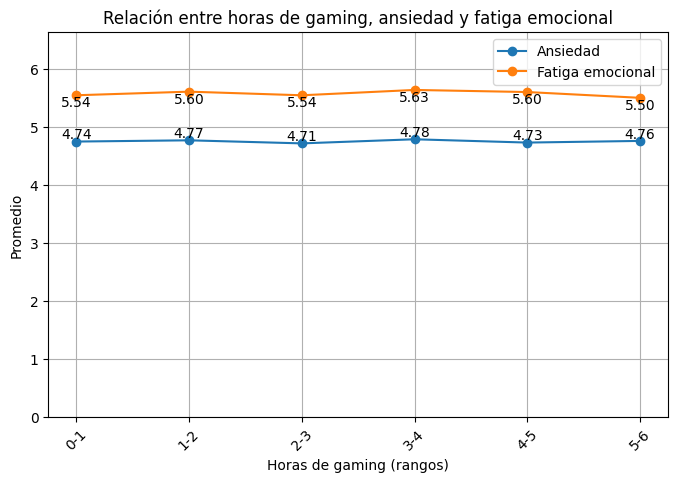

In [ ]:
bienestar['Gaming_grupos'] = pd.cut(
    bienestar['Online_Gaming_Hours'],
    bins=[0,1,2,3,4,5,6],
    labels=['0-1','1-2','2-3','3-4','4-5','5-6']
)

grupo = bienestar.groupby('Gaming_grupos')[['Anxiety_Score', 'Emotional_Fatigue_Score']].mean()

plt.figure(figsize=(8,5))

x = grupo.index.astype(str)

plt.plot(x, grupo['Anxiety_Score'], marker='o', label='Ansiedad')
plt.plot(x, grupo['Emotional_Fatigue_Score'], marker='o', label='Fatiga emocional')

for i, val in enumerate(grupo['Anxiety_Score']):
    plt.text(i, val, f'{val:.2f}', ha='center', va='bottom')

for i, val in enumerate(grupo['Emotional_Fatigue_Score']):
    plt.text(i, val, f'{val:.2f}', ha='center', va='top')

plt.title('Relación entre horas de gaming, ansiedad y fatiga emocional')
plt.xlabel('Horas de gaming (rangos)')
plt.ylabel('Promedio')

plt.xticks(rotation=45)
plt.grid()
plt.legend()

plt.ylim(0, max(grupo.max()) + 1)

plt.show()

Se observa una relación leve entre las horas de gaming y el bienestar emocional, donde la ansiedad y la fatiga aumentan ligeramente al inicio, pero luego se mantienen estables sin cambios significativos.

# Concluisones y hallazgos claves



*   Se observa un nivel moderado de ansiedad (4,75/10) junto con un alto porcentaje de burnout (53,88%), indicando un contexto general de riesgo en el bienestar emocional.
*   Las redes sociales muestran el mayor impacto negativo, con un aumento claro de ansiedad y fatiga a medida que crecen las horas de uso.

*   El gaming presenta una relación débil, con variaciones leves que se estabilizan rápidamente.
*   Se observa que los factores demográficos como la edad y el género no presentan diferencias significativas en el nivel de burnout. En cambio, los hábitos de estilo de vida, especialmente las horas de sueño, muestran una relación más clara, donde niveles más altos de burnout se asocian con menor cantidad de horas de descanso.

*La cantidad y calidad del sueño son factores clave: menos y peor sueño se asocia a mayor riesgo de burnout.*

In [13]:
bienestar.to_csv('dataset_bienestar.csv', index=False)